In [1]:
# Hello! I am a test cell. You can run me to see if your Python environment is working.
print("If it is working, it is working. If it is not, it is not.")

If it is working, it is working. If it is not, it is not.


# DSI Plotting

This notebook compares the electronics and fluides scores from `elec_fluides_matched_from_pdfs.csv`.

## Load the Dataset

First, we load the CSV with pandas and check the first rows.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# DO IT
df = pd.read_csv("elec_fluides_matched_from_pdfs.csv")
df.head()

,name,student_number,electronics,fluides
0,ADJAHOTO ANDREA,22002184,110,10
1,NGO VO NGOC HUY,22101368,105,45
2,BALKADI MOHAMED,22207168,175,140
3,CHERIFI IMEDEDDINE,22212242,125,35
4,COUTON DYLAN,22307407,190,145


## Clean and Prepare the Data

We keep the useful columns and create a new column that compares the two scores.

In [3]:
# TODO: prepare the dataset
df["electronics"] = pd.to_numeric(df["electronics"])
df["fluides"] = pd.to_numeric(df["fluides"])

df["difference"] = df["electronics"] - df["fluides"]
df["average"] = (df["electronics"] + df["fluides"]) / 2

df[["name", "student_number", "electronics", "fluides", "difference", "average"]].head()

,name,student_number,electronics,fluides,difference,average
0,ADJAHOTO ANDREA,22002184,110,10,100,60.0
1,NGO VO NGOC HUY,22101368,105,45,60,75.0
2,BALKADI MOHAMED,22207168,175,140,35,157.5
3,CHERIFI IMEDEDDINE,22212242,125,35,90,80.0
4,COUTON DYLAN,22307407,190,145,45,167.5


## General Statistics

This gives us a quick comparison of the distribution of both grades.

In [4]:
# DO IT
df[["electronics", "fluides", "difference", "average"]].describe()

,electronics,fluides,difference,average
count,221.000000,221.000000,221.000000,221.000000
mean,143.936652,90.135747,53.800905,117.036199
std,41.171764,46.097522,40.634582,38.694386
min,20.000000,0.000000,-55.000000,22.500000
25%,115.000000,55.000000,30.000000,90.000000
50%,150.000000,85.000000,50.000000,120.000000
75%,175.000000,120.000000,80.000000,147.500000
max,200.000000,200.000000,170.000000,197.500000


## Electronics vs Fluides Scatter Plot

Each point represents one student. The red dashed line shows where both scores would be equal.

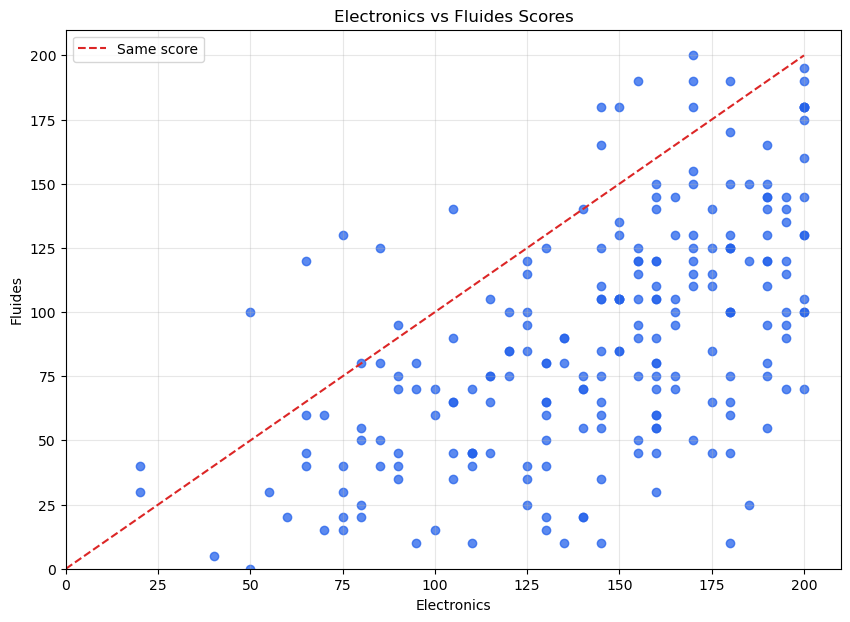

Correlation between electronics and fluides: 0.57


In [5]:
# DO IT
plt.figure(figsize=(10, 7))
plt.scatter(df["electronics"], df["fluides"], alpha=0.75, color="#2563EB")

plt.plot([0, 200], [0, 200], linestyle="--", color="#DC2626", label="Same score")

plt.title("Electronics vs Fluides Scores")
plt.xlabel("Electronics")
plt.ylabel("Fluides")
plt.xlim(0, 210)
plt.ylim(0, 210)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

correlation = df["electronics"].corr(df["fluides"])
print(f"Correlation between electronics and fluides: {correlation:.2f}")

## Average Scores by Subject

This bar chart compares the class average in electronics and fluides.

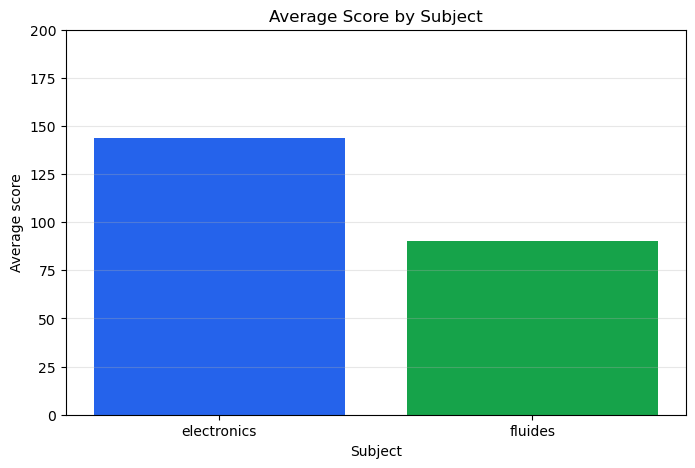

electronics    143.936652
fluides         90.135747
dtype: float64

In [6]:
# DO IT
subject_means = df[["electronics", "fluides"]].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_means.index, subject_means.values, color=["#2563EB", "#16A34A"])
plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average score")
plt.ylim(0, 200)
plt.grid(axis="y", alpha=0.3)
plt.show()

subject_means

## Which Subject Has the Higher Score?

Here we count how many students scored higher in electronics, higher in fluides, or the same in both.

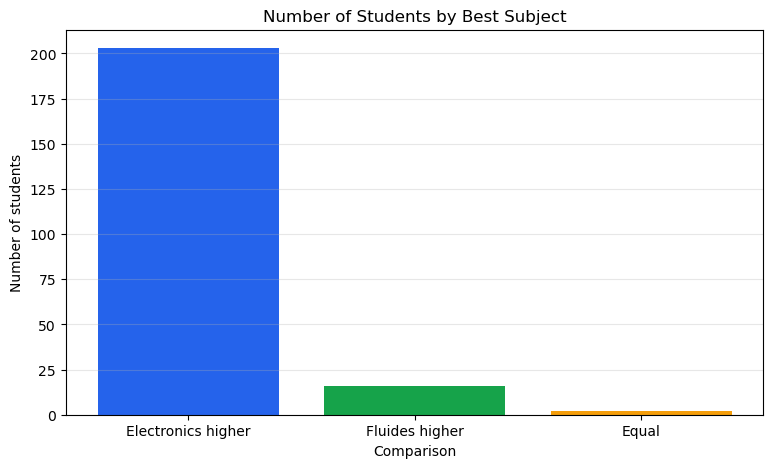

comparison
Electronics higher    203
Fluides higher         16
Equal                   2
Name: count, dtype: int64

In [7]:
# DO IT
def compare_scores(row):
    if row["electronics"] > row["fluides"]:
        return "Electronics higher"
    if row["fluides"] > row["electronics"]:
        return "Fluides higher"
    return "Equal"

df["comparison"] = df.apply(compare_scores, axis=1)
comparison_counts = df["comparison"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(comparison_counts.index, comparison_counts.values, color=["#2563EB", "#16A34A", "#F59E0B"])
plt.title("Number of Students by Best Subject")
plt.xlabel("Comparison")
plt.ylabel("Number of students")
plt.grid(axis="y", alpha=0.3)
plt.show()

comparison_counts

## Difference Distribution

The difference is calculated as `electronics - fluides`. Positive values mean electronics is higher.

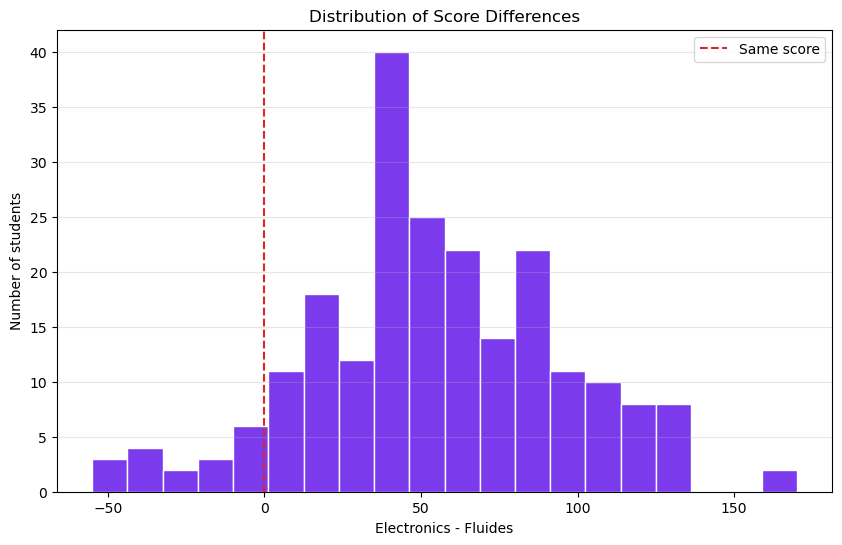

Average difference: 53.8
Median difference: 50.0


In [8]:
# DO IT
plt.figure(figsize=(10, 6))
plt.hist(df["difference"], bins=20, color="#7C3AED", edgecolor="white")
plt.axvline(0, color="#DC2626", linestyle="--", label="Same score")
plt.title("Distribution of Score Differences")
plt.xlabel("Electronics - Fluides")
plt.ylabel("Number of students")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

print("Average difference:", round(df["difference"].mean(), 2))
print("Median difference:", round(df["difference"].median(), 2))

## Biggest Differences

This table shows the students where the gap between electronics and fluides is the largest.

In [9]:
# DO IT
df_biggest_gaps = df.copy()
df_biggest_gaps["absolute_difference"] = df_biggest_gaps["difference"].abs()
df_biggest_gaps = df_biggest_gaps.sort_values("absolute_difference", ascending=False)

df_biggest_gaps[["name", "electronics", "fluides", "difference", "absolute_difference"]].head(10)

,name,electronics,fluides,difference,absolute_difference
80,BENARD NOLAN,180,10,170,170
173,LABIOLE GAEL,185,25,160,160
170,EMMANUEL DAVID,190,55,135,135
78,DONIS SIMON,145,10,135,135
125,RABIN ARTHUR,180,45,135,135
34,CAMPO MILAN,160,30,130,130
71,MENS UNAI,200,70,130,130
111,CHADAILLAT ZOE,175,45,130,130
184,ERGIN BEREN,195,70,125,125
124,DUBOURG ANTOINE,135,10,125,125


## Top 10 Students by Average Score

The average score combines both electronics and fluides.

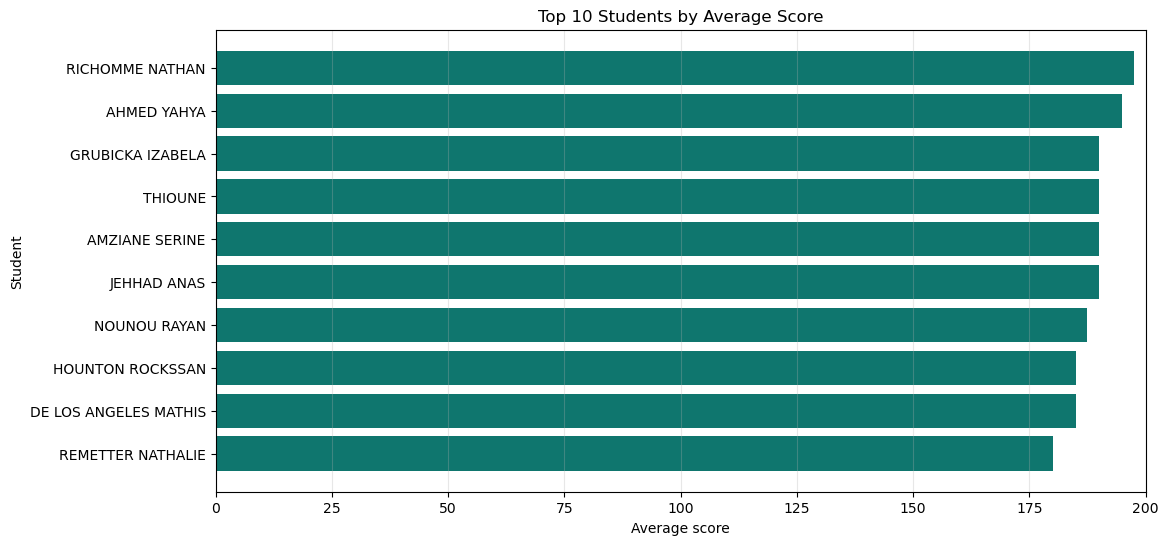

,name,electronics,fluides,average
168,RICHOMME NATHAN,200,195,197.5
193,AHMED YAHYA,200,190,195.0
57,GRUBICKA IZABELA,200,180,190.0
213,THIOUNE,200,180,190.0
207,AMZIANE SERINE,200,180,190.0
186,JEHHAD ANAS,200,180,190.0
48,NOUNOU RAYAN,200,175,187.5
218,HOUNTON ROCKSSAN,180,190,185.0
118,DE LOS ANGELES MATHIS,170,200,185.0
15,REMETTER NATHALIE,200,160,180.0


In [10]:
# DO IT
df_top_average = df.sort_values("average", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(df_top_average["name"], df_top_average["average"], color="#0F766E")
plt.title("Top 10 Students by Average Score")
plt.xlabel("Average score")
plt.ylabel("Student")
plt.xlim(0, 200)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

df_top_average[["name", "electronics", "fluides", "average"]]

## Conclusion

The final cell prints the main results from the comparison.

In [11]:
# DO IT
print("Number of students:", len(df))
print("Average electronics score:", round(df["electronics"].mean(), 2))
print("Average fluides score:", round(df["fluides"].mean(), 2))
print("Average difference:", round(df["difference"].mean(), 2))
print("Correlation:", round(df["electronics"].corr(df["fluides"]), 2))
print()
print(comparison_counts)

Number of students: 221
Average electronics score: 143.94
Average fluides score: 90.14
Average difference: 53.8
Correlation: 0.57

comparison
Electronics higher    203
Fluides higher         16
Equal                   2
Name: count, dtype: int64
